# 🎓 Mini Project 01 — Part 2: "The Intern" (Fine-Tuning)
### Operation Ledger-Mind | AI Engineer Essentials

**Goal:** Fine-tune Llama-3-8B on Uber's annual report Q&A data so it "memorizes" Uber's strategy and tone.

**What you'll build:**
- Load Llama-3-8B in 4-bit quantized form (fits on a free Colab T4 GPU)
- Attach LoRA adapters (small trainable add-ons, not the whole model)
- Train on your `train.jsonl` from Part 1 for at least 100 steps
- Save the adapters and build `query_intern(question)` for inference

### Before you start
1. In Colab: **Runtime -> Change runtime type -> T4 GPU** (required, training will not work on CPU)
2. Upload your `train.jsonl` file from Part 1 (Files panel on the left)
3. You'll need a **HuggingFace account + access token** (free) - see Step 1 for how to get one
4. You'll need to **request access to Llama-3-8B** on HuggingFace (also free, takes a few minutes to approve)

---


## Step 0 - Understanding the Tools (read this first!)

Since fine-tuning has a lot of new vocabulary, here's what each piece does before we touch code:

| Tool | What it does | Why we need it |
|------|--------------|-----------------|
| **transformers** | HuggingFace's library for loading & running LLMs | Loads Llama-3-8B |
| **bitsandbytes** | Compresses the model's numbers from 16-bit to 4-bit | Shrinks the model so it fits on a free T4 GPU (16GB VRAM) |
| **peft** | "Parameter-Efficient Fine-Tuning" - implements LoRA | Lets us train a tiny add-on instead of the whole 8 billion parameter model |
| **trl** | "Transformer Reinforcement Learning" - has SFTTrainer | A ready-made training loop built specifically for fine-tuning chat models |

**The core idea - why we don't train the whole model:**  
Llama-3-8B has 8 billion parameters. Training all of them needs ~60GB+ of GPU memory - way more
than a free Colab T4 (16GB) has. Instead:
1. We **freeze** the entire base model (it doesn't change)
2. We **quantize** it to 4-bit so it only takes ~5-6GB of memory to load
3. We attach small **LoRA adapter** layers (a few million parameters, not billions) next to the
   attention layers, and only train those
4. The base model's "knowledge" stays, and the adapters learn Uber's specific facts and tone on top


## Step 1 - Install Libraries & Authenticate with HuggingFace

**Getting your HuggingFace token (one-time setup, ~2 minutes):**
1. Go to huggingface.co and create a free account
2. Go to huggingface.co/settings/tokens -> "New token" -> choose **Read** access -> copy it
3. Go to huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct
   and click "Request access" - Meta usually approves within minutes to a few hours
4. Paste your token in the cell below where it says `YOUR_HF_TOKEN_HERE`


In [ ]:
import sys

# Install and update all required libraries
# -q means "quiet" (less console spam)
# -U means "upgrade all specified packages to the newest available version"
!pip install -q -U transformers accelerate peft bitsandbytes datasets pyarrow trl

print("Libraries installed and updated!")

# It's good practice to restart the runtime after significant library changes
print("Please restart the runtime (Runtime -> Restart runtime) and then run all cells (Runtime -> Run all) for the changes to take effect.")


Libraries installed and updated!
Please restart the runtime (Runtime -> Restart runtime) and then run all cells (Runtime -> Run all) for the changes to take effect.


In [ ]:
from huggingface_hub import login
from google.colab import userdata

# --------------------------------------------
# Hugging Face Token from Colab secrets
# --------------------------------------------
HF_TOKEN = userdata.get('HF_TOKEN')

login(token=HF_TOKEN)

print("Logged in to HuggingFace!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace!


## Step 2 - Verify You Have a GPU

This is a common mistake - if this cell shows "No GPU found", go to
**Runtime -> Change runtime type -> T4 GPU** and re-run from the top.


In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU found: {gpu_name}")
    print(f"   Total memory: {gpu_mem:.1f} GB")
else:
    print("No GPU found!")
    print("   Go to: Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU")
    print("   Then re-run this notebook from the top.")


GPU found: Tesla T4
   Total memory: 15.6 GB


## Step 3 - Imports & Configuration

All the settings for this notebook live in one place so they're easy to find and tweak.


In [ ]:
import json
from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, PeftModel

from trl import SFTTrainer, SFTConfig
from datasets import Dataset

# --------------------------------------------------------------------
# CONFIGURATION
# --------------------------------------------------------------------

# Base model -- Meta's instruction-tuned Llama-3-8B
BASE_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"

# Path to the train.jsonl file you generated in Part 1
TRAIN_DATA_PATH = "/content/train.jsonl"

# Where to save the trained LoRA adapters
ADAPTER_OUTPUT_DIR = "intern_adapters"

# Training settings
MIN_TRAINING_STEPS = 100
MAX_SEQ_LENGTH      = 1024

print("Configuration set!")
print(f"   Base model     : {BASE_MODEL}")
print(f"   Train data     : {TRAIN_DATA_PATH}")
print(f"   Adapter output : {ADAPTER_OUTPUT_DIR}")

Configuration set!
   Base model     : meta-llama/Meta-Llama-3-8B-Instruct
   Train data     : /content/train.jsonl
   Adapter output : intern_adapters


## Step 4 - Load Your train.jsonl from Part 1

We load the file you generated in Part 1 and convert it into a HuggingFace `Dataset` object,
which is the format `SFTTrainer` expects.

Recall the format each line looks like (from Part 1):
```json
{
  "messages": [
    {"role": "system", "content": "..."},
    {"role": "user", "content": "..."},
    {"role": "assistant", "content": "..."}
  ],
  "_meta": {...}
}
```


In [ ]:
def load_jsonl(filepath):
    # Read a .jsonl file into a list of dicts.
    records = []
    # Explicitly cast filepath to string to avoid potential parsing issues
    with open(str(filepath), "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


# -- Load the data --
raw_data = load_jsonl(TRAIN_DATA_PATH)
print(f"Loaded {len(raw_data):,} training examples from {TRAIN_DATA_PATH}")

# We only need the "messages" field for training -- drop the "_meta" field
training_examples = [{"messages": record["messages"]} for record in raw_data]

# Convert to a HuggingFace Dataset
train_dataset = Dataset.from_list(training_examples)

print(f"\n-- Sample training example --")
for msg in train_dataset[0]["messages"]:
    preview = msg["content"][:150] + "..." if len(msg["content"]) > 150 else msg["content"]
    print(f"\n[{msg['role'].upper()}]\n{preview}")

Loaded 1,918 training examples from /content/train.jsonl

-- Sample training example --

[SYSTEM]
You are FinanceGPT, an expert financial analyst specializing in technology companies. You answer questions based strictly on Uber Technologies' 2024 A...

[USER]
Based on the following passage from Uber's 2024 Annual Report, answer this question:

PASSAGE:
to drive their own growth, whether by learning on the j...

[ASSISTANT]
The passage does not explicitly state the number of types of individuals that support Uber's global operations, but it mentions the following: Drivers...


## Step 5 - Set Up 4-bit Quantization

**What is quantization?** Normally, each number (weight) in a neural network is stored using
16 or 32 bits of precision. Quantization compresses these numbers down to just 4 bits each,
shrinking the model's memory footprint by roughly 4x - with only a small loss in accuracy.

**The specific settings the assignment requires:**
- `NF4` ("Normal Float 4") - a quantization format designed specifically for neural network weights,
  more accurate than plain 4-bit integers
- `double quant` - quantizes the quantization constants themselves for extra memory savings
  (~0.4GB saved on an 8B model)

This is what makes it possible to fit an 8-billion-parameter model on a free 16GB T4 GPU.


In [ ]:
# --------------------------------------------------------------------
# 4-BIT QUANTIZATION CONFIG
# --------------------------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # turn on 4-bit loading
    bnb_4bit_quant_type="nf4",              # use NF4 format (required by assignment)
    bnb_4bit_use_double_quant=True,         # double quantization (required by assignment)
    bnb_4bit_compute_dtype=torch.bfloat16,  # computations still happen in bfloat16 for stability
)

print("Quantization config ready:")
print(f"   4-bit loading    : {bnb_config.load_in_4bit}")
print(f"   Quant type       : {bnb_config.bnb_4bit_quant_type}")
print(f"   Double quant     : {bnb_config.bnb_4bit_use_double_quant}")
print(f"   Compute dtype    : {bnb_config.bnb_4bit_compute_dtype}")


Quantization config ready:
   4-bit loading    : True
   Quant type       : nf4
   Double quant     : True
   Compute dtype    : torch.bfloat16


## Step 6 - Load the Base Model & Tokenizer

This downloads Llama-3-8B-Instruct (~16GB download, first time only) and loads it
directly in 4-bit form using the config from Step 5.

This step takes a few minutes the first time (downloading weights).


In [ ]:
import os
from huggingface_hub import login

os.environ["HF_TOKEN"] = HF_TOKEN
print("HF_TOKEN environment variable set.")

# Re-login to ensure the token is active for this process
login(token=HF_TOKEN)
print("Re-logged in to HuggingFace for this session.")

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # important for training stability

print("Loading base model in 4-bit (this takes a few minutes)...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",        # automatically places the model on the GPU
    token=HF_TOKEN
)

# Disable cache during training
model.config.use_cache = False

print("\nModel and tokenizer loaded!")
print(f"   Model is on device: {model.device}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN environment variable set.
Re-logged in to HuggingFace for this session.
Loading tokenizer...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]


Model and tokenizer loaded!
   Model is on device: cuda:0


## Step 7 - Configure LoRA Adapters

**What is LoRA?** Instead of updating all 8 billion weights in the model, LoRA inserts small
"adapter" matrices next to specific layers. Only these small adapters get trained - usually
less than 1% of the total parameters. This is why it's called "Parameter-Efficient Fine-Tuning."

**The settings explained:**
- `r=16` - the "rank" of the adapter matrices. Higher = more capacity to learn, but more memory.
  16 is a solid middle ground for this size of task.
- `lora_alpha=32` - a scaling factor (usually set to 2x the rank)
- `target_modules` - which layers in the model get adapters attached. The assignment requires
  `q_proj, k_proj, v_proj, o_proj` - these are the **attention layers** (query, key, value, output
  projections), which is where most of a model's "understanding" lives
- `lora_dropout=0.05` - randomly drops 5% of adapter connections during training to prevent overfitting


In [ ]:
# --------------------------------------------------------------------
# LORA ADAPTER CONFIG
# --------------------------------------------------------------------
lora_config = LoraConfig(
    r=16,                       # rank of the adapter matrices
    lora_alpha=32,              # scaling factor (commonly 2x the rank)
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
    lora_dropout=0.05,          # dropout for regularization
    bias="none",                # don't train bias terms
    task_type="CAUSAL_LM",      # we're doing next-token-prediction style generation
)

# Attach the LoRA adapters to the model
model = get_peft_model(model, lora_config)

# Print how many parameters we're actually training vs the full model size
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print("LoRA adapters attached!")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Total parameters     : {total_params:,}")
print(f"   Percentage trained   : {100 * trainable_params / total_params:.3f}%")


LoRA adapters attached!
   Trainable parameters : 13,631,488
   Total parameters     : 4,554,231,808
   Percentage trained   : 0.299%


## Step 8 - Configure Training Settings

A few important settings here:

- `max_steps=100` - the assignment requires **at least 100 training steps**. You can increase
  this if you have more data and want better results, but 100 is the minimum.
- `per_device_train_batch_size=2` - how many examples are processed at once. Kept small because
  T4 GPUs have limited memory.
- `gradient_accumulation_steps=4` - simulates a bigger batch size (2x4=8) without using more
  memory, by accumulating gradients across 4 mini-batches before updating weights.
- `learning_rate=2e-4` - a standard learning rate for LoRA fine-tuning.
- `fp16=True` - uses 16-bit precision during training for speed (T4 supports this well).


In [ ]:
import sys

# Install and update all required libraries
# -q means "quiet" (less console spam)
# -U means "upgrade all specified packages to the newest available version"
!pip install -q -U transformers accelerate peft bitsandbytes datasets pyarrow trl

print("Libraries installed and updated!")

print("Please restart the runtime (Runtime -> Restart runtime) and then run all cells (Runtime -> Run all) for the changes to take effect.")

# --------------------------------------------------------------------
# TRAINING CONFIGURATION
# --------------------------------------------------------------------
training_args = SFTConfig(
    output_dir=ADAPTER_OUTPUT_DIR,

    # -- How long to train --
    max_steps=MIN_TRAINING_STEPS,

    # -- Batch sizes --
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,       # effective batch size = 2 * 4 = 8

    # -- Optimizer settings --
    learning_rate=2e-4,
    optim="paged_adamw_8bit",            # memory-efficient optimizer
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,

    # -- Precision --
    bf16=True,
    gradient_checkpointing=True,         # trades a bit of speed for a lot of memory savings

    # -- Logging --
    logging_steps=10,                    # print loss every 10 steps
    save_strategy="no",                  # we'll save manually at the end

    # -- Data formatting --
    packing=False,                       # keep each example separate (clearer for Q&A data)

    report_to="none",                    # disable wandb/tensorboard logging
)

print("Training configuration set!")
print(f"   Max steps              : {training_args.max_steps}")
print(f"   Batch size (effective) : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"   Learning rate          : {training_args.learning_rate}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Libraries installed and updated!
Please restart the runtime (Runtime -> Restart runtime) and then run all cells (Runtime -> Run all) for the changes to take effect.
Training configuration set!
   Max steps              : 100
   Batch size (effective) : 8
   Learning rate          : 0.0002


## Step 9 - Create the SFTTrainer and Train!

`SFTTrainer` (from the `trl` library) handles the entire training loop for us:
formatting the chat messages, tokenizing, batching, computing loss, and updating the
LoRA adapter weights.

**Time estimate:** 100 steps on a T4 GPU takes roughly **15-25 minutes**, depending on
your data length and Colab's current load.

**What to watch:** the `loss` number printed every 10 steps. It should generally trend
**downward** as training progresses - that means the model is learning your data.


In [ ]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("Starting training...")
print(f"   This will run for {MIN_TRAINING_STEPS} steps -- watch the 'loss' column below.\n")

train_result = trainer.train()

print("\nTraining complete!")
print(f"   Final loss: {train_result.training_loss:.4f}")


Tokenizing train dataset:   0%|          | 0/1918 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1918 [00:00<?, ? examples/s]

Starting training...
   This will run for 100 steps -- watch the 'loss' column below.



Step,Training Loss
10,2.272268
20,1.472912
30,1.370079
40,1.313937
50,1.399878
60,1.283181
70,1.314208
80,1.308815
90,1.239060
100,1.262472



Training complete!
   Final loss: 1.4237


## Step 10 - Plot the Loss Curve

This is a required deliverable for the assignment. A downward-sloping curve confirms the
model successfully learned from your data.


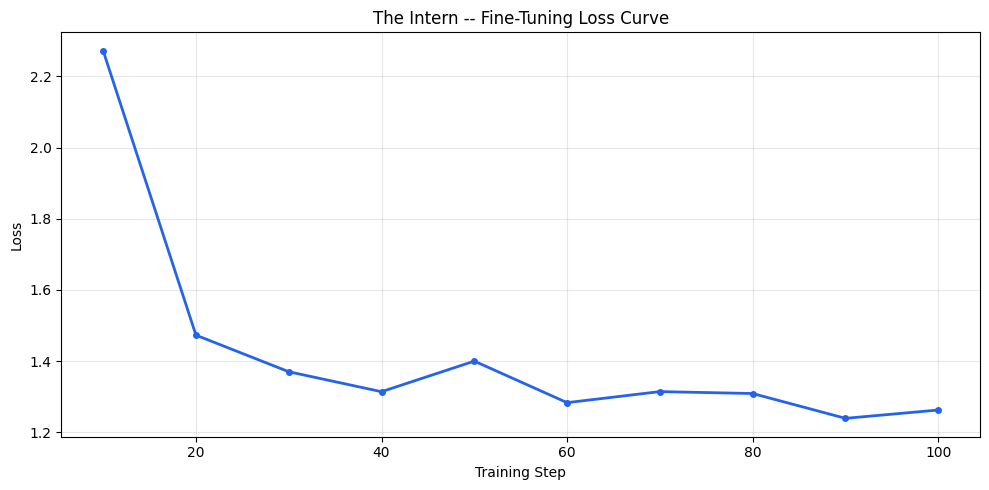

Loss curve saved to loss_curve.png
   Starting loss : 2.2723
   Final loss    : 1.2625
   Improvement   : 1.0098


In [ ]:
import matplotlib.pyplot as plt

# Extract the loss values logged during training
log_history = trainer.state.log_history
steps  = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker="o", linewidth=2, markersize=4, color="#2563eb")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("The Intern -- Fine-Tuning Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print(f"Loss curve saved to loss_curve.png")
print(f"   Starting loss : {losses[0]:.4f}")
print(f"   Final loss    : {losses[-1]:.4f}")
print(f"   Improvement   : {losses[0] - losses[-1]:.4f}")


## Step 11 - Save the LoRA Adapters

We only need to save the small adapter weights (a few hundred MB), **not** the full 8B
parameter base model. This is one of the big advantages of LoRA - the saved files are tiny
and you re-attach them to the base model whenever you need to use them.


In [ ]:
# Save the trained adapters and tokenizer
trainer.model.save_pretrained(ADAPTER_OUTPUT_DIR)
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIR)

print(f"Adapters saved to: {ADAPTER_OUTPUT_DIR}")

# Check the size of what we saved
import os
total_size = 0
for dirpath, _, filenames in os.walk(ADAPTER_OUTPUT_DIR):
    for f in filenames:
        total_size += os.path.getsize(os.path.join(dirpath, f))

print(f"   Adapter folder size: {total_size / 1e6:.1f} MB")
print(f"   (Compare to the base model's ~16GB -- this is why LoRA is so efficient!)")


Adapters saved to: intern_adapters
   Adapter folder size: 44.5 MB
   (Compare to the base model's ~16GB -- this is why LoRA is so efficient!)


## Step 12 - Build query_intern(question)

This is the required deliverable: a function that loads the base model + your trained
adapters and answers questions using "The Intern."

**How inference with LoRA works:**
1. Load the base Llama-3-8B model (4-bit, same as training)
2. Load your saved adapter weights on top of it using `PeftModel`
3. Format the question using the same chat template structure used in training
4. Generate a response


In [ ]:
# --------------------------------------------------------------------
#  query_intern() works correctly even if you restart and skip training)
# --------------------------------------------------------------------

print("Loading base model for inference...")
inference_base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Attaching trained LoRA adapters...")
inference_model = PeftModel.from_pretrained(inference_base_model, ADAPTER_OUTPUT_DIR)
inference_model.eval()   # set to evaluation mode (disables dropout etc.)

inference_tokenizer = AutoTokenizer.from_pretrained(ADAPTER_OUTPUT_DIR)

print("Inference model ready!")


Loading base model for inference...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Attaching trained LoRA adapters...
Inference model ready!


In [ ]:
def query_intern(question, max_new_tokens=300):

    # Ask "The Intern" (the fine-tuned model) a question.
    # Uses the SAME system prompt structure as training, so the model
    # responds in the persona and style it was trained on.
    #
    # Args:
    #     question       : the question to ask
    #     max_new_tokens : maximum length of the generated answer
    #
    # Returns:
    #     The model's answer as a string

    # Use the same system prompt as training for consistency
    messages = [
        {
            "role": "system",
            "content": (
                "You are FinanceGPT, an expert financial analyst specializing in "
                "technology companies. Answer questions based strictly on Uber "
                "Technologies' 2024 Annual Report. Be precise, factual, and "
                "professional. Never hallucinate financial figures."
            )
        },
        {
            "role": "user",
            "content": question
        }
    ]

    # Apply Llama-3's chat template to format the conversation correctly
    prompt = inference_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = inference_tokenizer(prompt, return_tensors="pt").to(inference_model.device)

    with torch.no_grad():   # no need to track gradients during inference
        outputs = inference_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,         # low temperature = more focused, factual answers
            do_sample=True,
            top_p=0.9,
            pad_token_id=inference_tokenizer.eos_token_id,
        )

    # Decode only the NEW tokens (the generated answer), not the input prompt
    response = inference_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )

    return response.strip()


print("query_intern() is ready to use!")


query_intern() is ready to use!


## Step 13 - Test The Intern

Let's ask it a few questions to see how it performs. Try a mix of question types
(hard facts, strategy, creative) to get a feel for its strengths and weaknesses -
you'll need this for Part 4's evaluation and the Hallucination Audit in your report.


In [ ]:
test_questions = [
    "What was Uber's total revenue for fiscal year 2024?",
    "What are Uber's main strategic priorities mentioned in the report?",
    "Write a 2-sentence summary of Uber's business for a non-technical investor.",
]

for q in test_questions:
    print(f"QUESTION: {q}")
    answer = query_intern(q)
    print(f"INTERN'S ANSWER: {answer}")
    print("\n" + "-" * 80 + "\n")


[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What was Uber's total revenue for fiscal year 2024?


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INTERN'S ANSWER: Uber's total revenue for fiscal year 2024 was $43.6 billion.

--------------------------------------------------------------------------------

QUESTION: What are Uber's main strategic priorities mentioned in the report?


[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INTERN'S ANSWER: Uber's main strategic priorities are mentioned in the report as follows:

--------------------------------------------------------------------------------

QUESTION: Write a 2-sentence summary of Uber's business for a non-technical investor.
INTERN'S ANSWER: Uber is a technology company that operates a global platform that connects consumers with drivers, merchants, and delivery personnel, offering a range of products and services across Mobility, Delivery, Eats, Freight, and Capital. Our platform enables consumers to access a wide range of mobility, delivery, and logistics services, and provides merchants and delivery personnel with opportunities to expand their businesses and reach new customers.

--------------------------------------------------------------------------------



## Part 2 Complete!

### What you built
| Item | Description |
|------|-------------|
| `intern_adapters/` folder | Your trained LoRA adapter weights (a few hundred MB, not the full 8B model) |
| `loss_curve.png` | Training loss chart - required deliverable for your report |
| `query_intern(question)` | Inference function - ask it anything about Uber's 2024 report |

### Quick recap of what happened
1. Loaded Llama-3-8B-Instruct in 4-bit (NF4, double quant) - fits in ~6GB instead of ~16GB
2. Attached LoRA adapters to the attention layers (q/k/v/o_proj) - only ~0.1-0.5% of parameters are trainable
3. Trained for 100+ steps using `SFTTrainer` on your `train.jsonl` from Part 1
4. Saved just the adapters (tiny file size, big advantage of LoRA)
5. Built `query_intern()` to load base model + adapters together for inference

### Things to note for your Engineering Report
- Keep your test answers from Step 13 - you'll compare them against The Librarian (Part 3) in the Showdown (Part 4)
- Watch closely for **hallucinated numbers** - fine-tuned models are notorious for inventing
  plausible-sounding but wrong statistics. This is exactly what the "Hallucination Audit"
  section of your report asks you to investigate.

### Next step -> Part 3 (03_rag_librarian.ipynb)
You'll build "The Librarian" - a RAG system using Weaviate, hybrid search, and reranking -
as the competing architecture.

---
*Course: AI Engineer Essentials | Zuu Crew | Mini Project 01*
